# Week 3 — Feature Selection, PCR, and PLSR

Applying forward/backward selection, PCR, and PLSR to three healthcare datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.feature_selection import SequentialFeatureSelector

## Load Data

In [2]:
df1 = pd.read_csv('df1_preprocessed.csv')
df2 = pd.read_csv('df2_preprocessed.csv')
df3 = pd.read_csv('df3_preprocessed.csv')

print(df1.shape, df2.shape, df3.shape)

(433323, 19) (101766, 123) (5109, 18)


## Helper Functions

In [3]:
# continuous cols to scale for each dataset
CONTINUOUS = {
    'df1': ['_BMI5', 'MENTHLTH', 'PHYSHLTH'],
    'df2': ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses'],
    'df3': ['age', 'avg_glucose_level', 'bmi']
}

def prep(df, target, drop_cols=[]):
    X = df.drop(columns=[target] + drop_cols)
    y = df[target]
    mask = y.notna() & X.notna().all(axis=1)
    return X[mask], y[mask]

def split_scale(X, y, cont_cols):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_test = X_train.astype(float).copy(), X_test.astype(float).copy()
    cols = [c for c in cont_cols if c in X_train.columns]
    scaler = StandardScaler()
    X_train[cols] = scaler.fit_transform(X_train[cols])
    X_test[cols]  = scaler.transform(X_test[cols])
    return X_train, X_test, y_train, y_test

def evaluate(model, X_test, y_test, label, is_pls=False):
    prob = model.predict(X_test).ravel() if is_pls else model.predict(X_test)
    pred = (prob >= 0.5).astype(int)
    print(f'\n--- {label} ---')
    print(classification_report(y_test, pred))
    print(confusion_matrix(y_test, pred))
    auc = roc_auc_score(y_test, prob)
    print(f'AUC: {auc:.4f}')
    return prob, auc

def plot_roc(y_test, results, title):
    plt.figure(figsize=(8, 5))
    for label, prob in results.items():
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(title); plt.legend(fontsize=9)
    plt.tight_layout(); plt.show()

---
## Dataset 1 — Diabetes (`DIABETE4`)

In [4]:
df1_model = df1[df1['DIABETE4'].isin([0,1])].copy()
X1, y1 = prep(df1_model, target='DIABETE4', drop_cols=['_RFCHOL3'])
X1_train, X1_test, y1_train, y1_test = split_scale(X1, y1, CONTINUOUS['df1'])
print(X1_train.shape, X1_test.shape)

(220707, 17) (55177, 17)


In [5]:
# Baseline
lr1 = LinearRegression().fit(X1_train, y1_train)
prob1_base, auc1_base = evaluate(lr1, X1_test, y1_test, 'DF1 Baseline')


--- DF1 Baseline ---
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.62      0.04      0.08      7918

    accuracy                           0.86     55177
   macro avg       0.74      0.52      0.50     55177
weighted avg       0.83      0.86      0.80     55177

[[47050   209]
 [ 7581   337]]
AUC: 0.8139


In [6]:
# Forward selection
fwd1 = SequentialFeatureSelector(LinearRegression(), direction='forward',
                                  n_features_to_select='auto', scoring='r2', cv=5)
fwd1.fit(X1_train, y1_train)
feats_fwd1 = X1_train.columns[fwd1.get_support()].tolist()
print(f'Forward selected {len(feats_fwd1)} features:', feats_fwd1)

lr1_fwd = LinearRegression().fit(X1_train[feats_fwd1], y1_train)
prob1_fwd, auc1_fwd = evaluate(lr1_fwd, X1_test[feats_fwd1], y1_test, 'DF1 Forward')

Forward selected 8 features: ['_RFHYPE6', '_CHOLCH3', '_BMI5', '_MICHD', 'EXERANY2', 'GENHLTH', 'DIFFWALK', '_AGEG5YR']

--- DF1 Forward ---
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.59      0.04      0.07      7918

    accuracy                           0.86     55177
   macro avg       0.73      0.52      0.50     55177
weighted avg       0.82      0.86      0.80     55177

[[47053   206]
 [ 7618   300]]
AUC: 0.8111


In [7]:
# Backward selection
bwd1 = SequentialFeatureSelector(LinearRegression(), direction='backward',
                                  n_features_to_select='auto', scoring='r2', cv=5)
bwd1.fit(X1_train, y1_train)
feats_bwd1 = X1_train.columns[bwd1.get_support()].tolist()
print(f'Backward selected {len(feats_bwd1)} features:', feats_bwd1)
print('Selected by both:', sorted(set(feats_fwd1) & set(feats_bwd1)))

lr1_bwd = LinearRegression().fit(X1_train[feats_bwd1], y1_train)
prob1_bwd, auc1_bwd = evaluate(lr1_bwd, X1_test[feats_bwd1], y1_test, 'DF1 Backward')

Backward selected 9 features: ['_RFHYPE6', '_CHOLCH3', '_BMI5', '_MICHD', 'EXERANY2', 'GENHLTH', 'DIFFWALK', '_AGEG5YR', '_INCOMG1']
Selected by both: ['DIFFWALK', 'EXERANY2', 'GENHLTH', '_AGEG5YR', '_BMI5', '_CHOLCH3', '_MICHD', '_RFHYPE6']

--- DF1 Backward ---
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.60      0.04      0.07      7918

    accuracy                           0.86     55177
   macro avg       0.73      0.52      0.50     55177
weighted avg       0.82      0.86      0.80     55177

[[47061   198]
 [ 7616   302]]
AUC: 0.8122


Components for 95% variance: 2


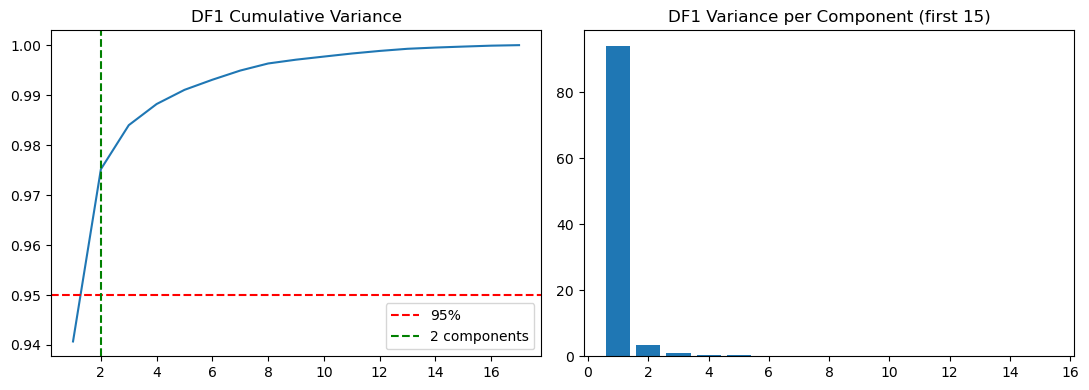


--- DF1 PCR (2 components) ---
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.00      0.00      0.00      7918

    accuracy                           0.86     55177
   macro avg       0.43      0.50      0.46     55177
weighted avg       0.73      0.86      0.79     55177

[[47259     0]
 [ 7918     0]]
AUC: 0.6888


In [8]:
# PCR — find number of components that explain 95% of variance, then regress
pca_full1 = PCA().fit(X1_train)
cumvar1 = np.cumsum(pca_full1.explained_variance_ratio_)
n_comp1 = np.argmax(cumvar1 >= 0.95) + 1
print(f'Components for 95% variance: {n_comp1}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, len(cumvar1)+1), cumvar1)
ax[0].axhline(0.95, color='red', linestyle='--', label='95%')
ax[0].axvline(n_comp1, color='green', linestyle='--', label=f'{n_comp1} components')
ax[0].set_title('DF1 Cumulative Variance'); ax[0].legend()

ax[1].bar(range(1, 16), pca_full1.explained_variance_ratio_[:15] * 100)
ax[1].set_title('DF1 Variance per Component (first 15)')
plt.tight_layout(); plt.show()

pca1 = PCA(n_components=n_comp1)
X1_train_pca = pca1.fit_transform(X1_train)
X1_test_pca  = pca1.transform(X1_test)

lr1_pcr = LinearRegression().fit(X1_train_pca, y1_train)
prob1_pcr, auc1_pcr = evaluate(lr1_pcr, X1_test_pca, y1_test, f'DF1 PCR ({n_comp1} components)')

Best PLS components: 6 (AUC=0.8139)


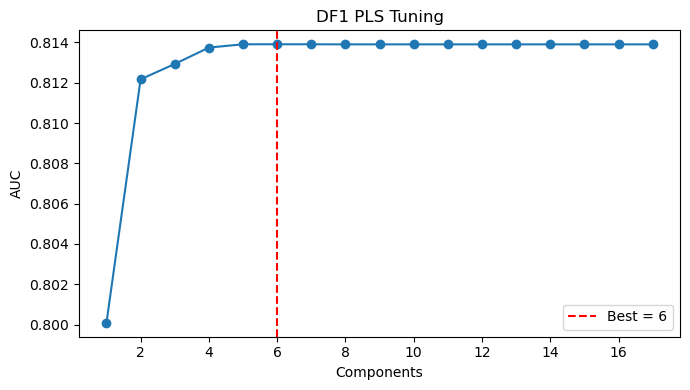


--- DF1 PLSR (6 components) ---
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92     47259
         1.0       0.62      0.04      0.08      7918

    accuracy                           0.86     55177
   macro avg       0.74      0.52      0.50     55177
weighted avg       0.83      0.86      0.80     55177

[[47049   210]
 [ 7581   337]]
AUC: 0.8139


In [9]:
# PLSR — tune number of components by AUC on test set
max_comp1 = min(20, X1_train.shape[1])
aucs1 = []
for n in range(1, max_comp1 + 1):
    pls = PLSRegression(n_components=n).fit(X1_train, y1_train)
    aucs1.append(roc_auc_score(y1_test, pls.predict(X1_test).ravel()))

best_n1 = np.argmax(aucs1) + 1
print(f'Best PLS components: {best_n1} (AUC={max(aucs1):.4f})')

plt.figure(figsize=(7, 4))
plt.plot(range(1, max_comp1+1), aucs1, marker='o')
plt.axvline(best_n1, color='red', linestyle='--', label=f'Best = {best_n1}')
plt.xlabel('Components'); plt.ylabel('AUC')
plt.title('DF1 PLS Tuning'); plt.legend(); plt.tight_layout(); plt.show()

pls1 = PLSRegression(n_components=best_n1).fit(X1_train, y1_train)
prob1_pls, auc1_pls = evaluate(pls1, X1_test, y1_test, f'DF1 PLSR ({best_n1} components)', is_pls=True)

   Model  Features/Components      AUC
Baseline                   17 0.813903
 Forward                    8 0.811066
Backward                    9 0.812192
     PCR                    2 0.688760
    PLSR                    6 0.813908


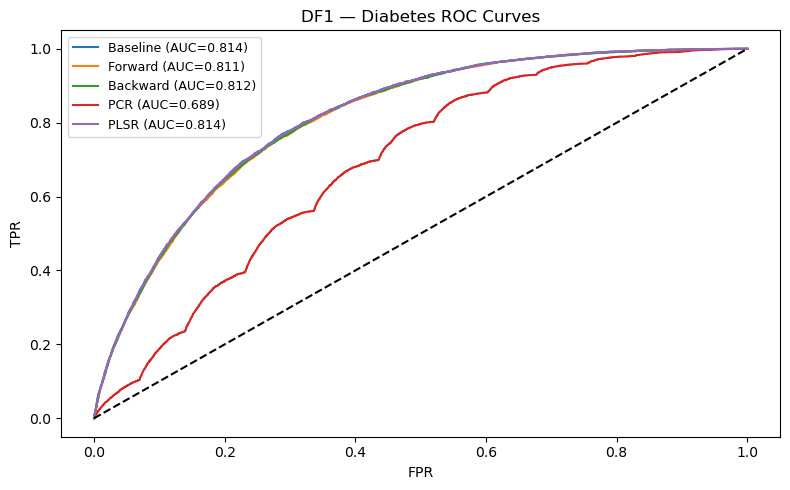

In [10]:
# Summary
summary1 = pd.DataFrame({
    'Model': ['Baseline', 'Forward', 'Backward', 'PCR', 'PLSR'],
    'Features/Components': [X1_train.shape[1], len(feats_fwd1), len(feats_bwd1), n_comp1, best_n1],
    'AUC': [auc1_base, auc1_fwd, auc1_bwd, auc1_pcr, auc1_pls]
})
print(summary1.to_string(index=False))

plot_roc(y1_test, {
    'Baseline': prob1_base, 'Forward': prob1_fwd,
    'Backward': prob1_bwd, 'PCR': prob1_pcr, 'PLSR': prob1_pls
}, 'DF1 — Diabetes ROC Curves')

---
## Dataset 2 — Hospital Readmission (`readmitted`)

> df2 has 100+ columns so backward selection will be slow.

In [11]:
X2, y2 = prep(df2, target='readmitted')
X2_train, X2_test, y2_train, y2_test = split_scale(X2, y2, CONTINUOUS['df2'])
print(X2_train.shape, X2_test.shape)

(238, 122) (60, 122)


In [12]:
lr2 = LinearRegression().fit(X2_train, y2_train)
prob2_base, auc2_base = evaluate(lr2, X2_test, y2_test, 'DF2 Baseline')


--- DF2 Baseline ---
              precision    recall  f1-score   support

           0       0.88      0.85      0.87        53
           1       0.11      0.14      0.12         7

    accuracy                           0.77        60
   macro avg       0.50      0.50      0.50        60
weighted avg       0.79      0.77      0.78        60

[[45  8]
 [ 6  1]]
AUC: 0.6011


In [13]:
fwd2 = SequentialFeatureSelector(LinearRegression(), direction='forward',
                                  n_features_to_select='auto', scoring='r2', cv=5)
fwd2.fit(X2_train, y2_train)
feats_fwd2 = X2_train.columns[fwd2.get_support()].tolist()
print(f'Forward selected {len(feats_fwd2)} features:', feats_fwd2)

lr2_fwd = LinearRegression().fit(X2_train[feats_fwd2], y2_train)
prob2_fwd, auc2_fwd = evaluate(lr2_fwd, X2_test[feats_fwd2], y2_test, 'DF2 Forward')

Forward selected 61 features: ['number_emergency', 'number_inpatient', 'repaglinide', 'nateglinide', 'glimepiride', 'acetohexamide', 'glipizide', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'diag_1_Digestive', 'diag_1_Genitourinary', 'diag_1_Injury', 'diag_1_Musculoskeletal', 'diag_1_Unknown', 'diag_2_Injury', 'diag_2_Musculoskeletal', 'diag_3_Digestive', 'diag_3_Other', 'admission_type_id_4', 'admission_type_id_5', 'admission_type_id_7', 'admission_type_id_8', 'discharge_disposition_id_3', 'discharge_disposition_id_4', 'discharge_disposition_id_8', 'discharge_disposition_id_9', 'discharge_disposition_id_11', 'discharge_disposition_id_12', 'discharge_disposition_id_14', 'discharge_disposition_id_15', 'discharge_disposition_id_16', 'discharge_disposition_id_17', 'discharge_disposition_id_18', 'discharge_disposition_id_19', 'discharge_disposition_id_20', 'discharge_disposition_id_22', 'discharge_disposition_id_23', 'discharge_disposition_id_24', 'disch

In [14]:
bwd2 = SequentialFeatureSelector(LinearRegression(), direction='backward',
                                  n_features_to_select='auto', scoring='r2', cv=5)
bwd2.fit(X2_train, y2_train)
feats_bwd2 = X2_train.columns[bwd2.get_support()].tolist()
print(f'Backward selected {len(feats_bwd2)} features:', feats_bwd2)
print('Both:', sorted(set(feats_fwd2) & set(feats_bwd2)))

lr2_bwd = LinearRegression().fit(X2_train[feats_bwd2], y2_train)
prob2_bwd, auc2_bwd = evaluate(lr2_bwd, X2_test[feats_bwd2], y2_test, 'DF2 Backward')

Backward selected 61 features: ['number_inpatient', 'number_diagnoses', 'glimepiride', 'acetohexamide', 'glipizide', 'tolbutamide', 'pioglitazone', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'diag_1_Digestive', 'diag_1_Genitourinary', 'diag_1_Injury', 'diag_1_Unknown', 'diag_2_Injury', 'diag_2_Musculoskeletal', 'diag_2_Other', 'diag_3_Circulatory', 'diag_3_Diabetes', 'diag_3_Genitourinary', 'diag_3_Injury', 'diag_3_Musculoskeletal', 'diag_3_Other', 'diag_3_Respiratory', 'diag_3_Unknown', 'admission_type_id_1', 'admission_type_id_2', 'admission_type_id_3', 'admission_type_id_4', 'admission_type_id_5', 'admission_type_id_6', 'admission_type_id_8', 'discharge_disposition_id_3', 'discharge_disposition_id_4', 'discharge_disposition_id_8', 'discharge_disposition_id_9', 'discharge_disposition_id_12', 'discharge_disposition_id_15', 'discharge_disposition_id_16', 'discha

Components for 95% variance: 31


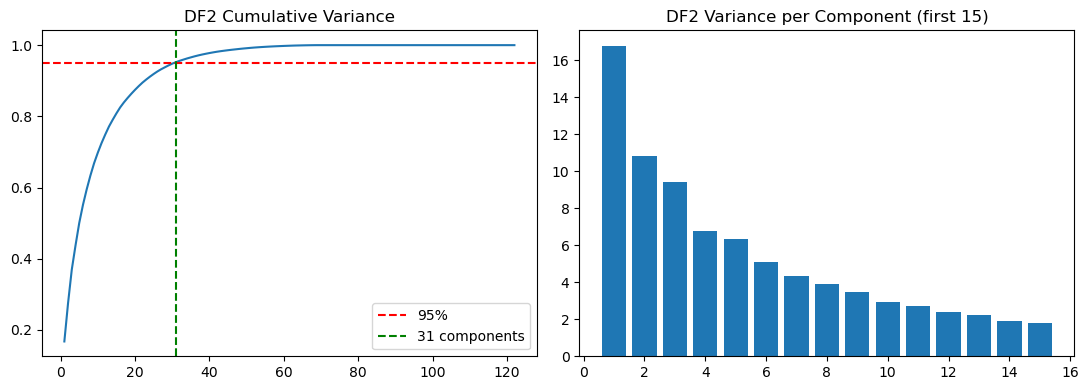


--- DF2 PCR (31 components) ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        53
           1       0.00      0.00      0.00         7

    accuracy                           0.87        60
   macro avg       0.44      0.49      0.46        60
weighted avg       0.78      0.87      0.82        60

[[52  1]
 [ 7  0]]
AUC: 0.5337


In [15]:
pca_full2 = PCA().fit(X2_train)
cumvar2 = np.cumsum(pca_full2.explained_variance_ratio_)
n_comp2 = np.argmax(cumvar2 >= 0.95) + 1
print(f'Components for 95% variance: {n_comp2}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, len(cumvar2)+1), cumvar2)
ax[0].axhline(0.95, color='red', linestyle='--', label='95%')
ax[0].axvline(n_comp2, color='green', linestyle='--', label=f'{n_comp2} components')
ax[0].set_title('DF2 Cumulative Variance'); ax[0].legend()
ax[1].bar(range(1, 16), pca_full2.explained_variance_ratio_[:15] * 100)
ax[1].set_title('DF2 Variance per Component (first 15)')
plt.tight_layout(); plt.show()

pca2 = PCA(n_components=n_comp2)
X2_train_pca = pca2.fit_transform(X2_train)
X2_test_pca  = pca2.transform(X2_test)

lr2_pcr = LinearRegression().fit(X2_train_pca, y2_train)
prob2_pcr, auc2_pcr = evaluate(lr2_pcr, X2_test_pca, y2_test, f'DF2 PCR ({n_comp2} components)')

Best PLS components: 2 (AUC=0.6900)


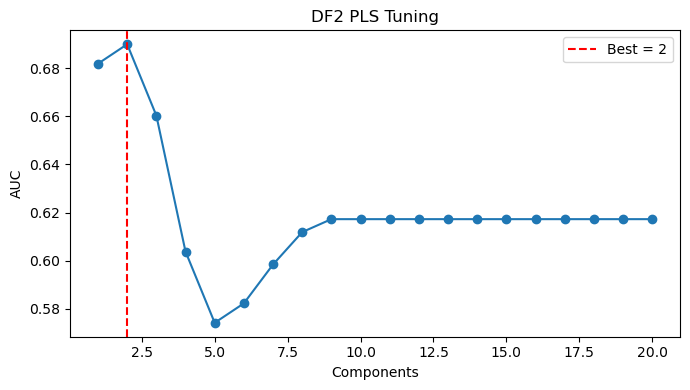


--- DF2 PLSR (2 components) ---
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        53
           1       0.14      0.14      0.14         7

    accuracy                           0.80        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.80      0.80      0.80        60

[[47  6]
 [ 6  1]]
AUC: 0.6900


In [16]:
max_comp2 = min(20, X2_train.shape[1])
aucs2 = []
for n in range(1, max_comp2 + 1):
    pls = PLSRegression(n_components=n).fit(X2_train, y2_train)
    aucs2.append(roc_auc_score(y2_test, pls.predict(X2_test).ravel()))

best_n2 = np.argmax(aucs2) + 1
print(f'Best PLS components: {best_n2} (AUC={max(aucs2):.4f})')

plt.figure(figsize=(7, 4))
plt.plot(range(1, max_comp2+1), aucs2, marker='o')
plt.axvline(best_n2, color='red', linestyle='--', label=f'Best = {best_n2}')
plt.xlabel('Components'); plt.ylabel('AUC')
plt.title('DF2 PLS Tuning'); plt.legend(); plt.tight_layout(); plt.show()

pls2 = PLSRegression(n_components=best_n2).fit(X2_train, y2_train)
prob2_pls, auc2_pls = evaluate(pls2, X2_test, y2_test, f'DF2 PLSR ({best_n2} components)', is_pls=True)

   Model  Features/Components      AUC
Baseline                  122 0.601078
 Forward                   61 0.734501
Backward                   61 0.823450
     PCR                   31 0.533693
    PLSR                    2 0.690027


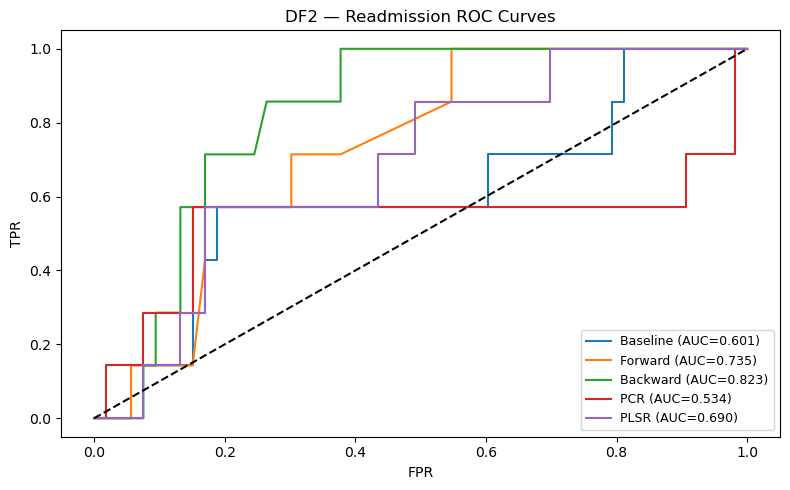

In [17]:
summary2 = pd.DataFrame({
    'Model': ['Baseline', 'Forward', 'Backward', 'PCR', 'PLSR'],
    'Features/Components': [X2_train.shape[1], len(feats_fwd2), len(feats_bwd2), n_comp2, best_n2],
    'AUC': [auc2_base, auc2_fwd, auc2_bwd, auc2_pcr, auc2_pls]
})
print(summary2.to_string(index=False))

plot_roc(y2_test, {
    'Baseline': prob2_base, 'Forward': prob2_fwd,
    'Backward': prob2_bwd, 'PCR': prob2_pcr, 'PLSR': prob2_pls
}, 'DF2 — Readmission ROC Curves')

---
## Dataset 3 — Stroke (`stroke`)

> Stroke is only ~5% of cases, so accuracy is misleading — use AUC.

In [18]:
X3, y3 = prep(df3, target='stroke')
X3_train, X3_test, y3_train, y3_test = split_scale(X3, y3, CONTINUOUS['df3'])
print(X3_train.shape, X3_test.shape)
print(y3.value_counts(normalize=True).round(3))

(4087, 17) (1022, 17)
stroke
0    0.951
1    0.049
Name: proportion, dtype: float64


In [19]:
lr3 = LinearRegression().fit(X3_train, y3_train)
prob3_base, auc3_base = evaluate(lr3, X3_test, y3_test, 'DF3 Baseline')


--- DF3 Baseline ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

[[972   0]
 [ 50   0]]
AUC: 0.8240


In [20]:
fwd3 = SequentialFeatureSelector(LinearRegression(), direction='forward',
                                  n_features_to_select='auto', scoring='r2', cv=5)
fwd3.fit(X3_train, y3_train)
feats_fwd3 = X3_train.columns[fwd3.get_support()].tolist()
print(f'Forward selected {len(feats_fwd3)} features:', feats_fwd3)

lr3_fwd = LinearRegression().fit(X3_train[feats_fwd3], y3_train)
prob3_fwd, auc3_fwd = evaluate(lr3_fwd, X3_test[feats_fwd3], y3_test, 'DF3 Forward')

Forward selected 8 features: ['age', 'hypertension', 'ever_married', 'avg_glucose_level', 'bmi', 'work_type_Never_worked', 'work_type_children', 'smoking_status_Unknown']

--- DF3 Forward ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

[[972   0]
 [ 50   0]]
AUC: 0.8165


In [21]:
bwd3 = SequentialFeatureSelector(LinearRegression(), direction='backward',
                                  n_features_to_select='auto', scoring='r2', cv=5)
bwd3.fit(X3_train, y3_train)
feats_bwd3 = X3_train.columns[bwd3.get_support()].tolist()
print(f'Backward selected {len(feats_bwd3)} features:', feats_bwd3)
print('Both:', sorted(set(feats_fwd3) & set(feats_bwd3)))

lr3_bwd = LinearRegression().fit(X3_train[feats_bwd3], y3_train)
prob3_bwd, auc3_bwd = evaluate(lr3_bwd, X3_test[feats_bwd3], y3_test, 'DF3 Backward')

Backward selected 9 features: ['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed', 'smoking_status_Unknown']
Both: ['age', 'avg_glucose_level', 'ever_married', 'hypertension', 'smoking_status_Unknown']

--- DF3 Backward ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

[[972   0]
 [ 50   0]]
AUC: 0.8247


Components for 95% variance: 11


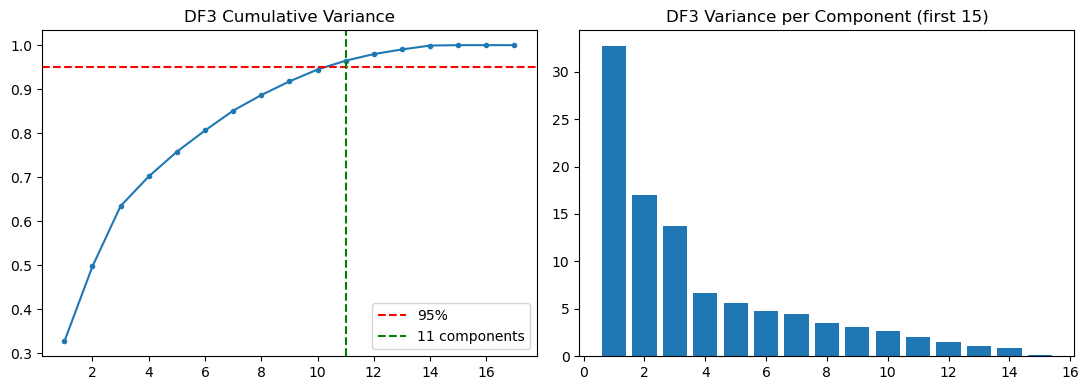


--- DF3 PCR (11 components) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

[[972   0]
 [ 50   0]]
AUC: 0.8187


In [22]:
pca_full3 = PCA().fit(X3_train)
cumvar3 = np.cumsum(pca_full3.explained_variance_ratio_)
n_comp3 = np.argmax(cumvar3 >= 0.95) + 1
print(f'Components for 95% variance: {n_comp3}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, len(cumvar3)+1), cumvar3, marker='o', markersize=3)
ax[0].axhline(0.95, color='red', linestyle='--', label='95%')
ax[0].axvline(n_comp3, color='green', linestyle='--', label=f'{n_comp3} components')
ax[0].set_title('DF3 Cumulative Variance'); ax[0].legend()
ax[1].bar(range(1, 16), pca_full3.explained_variance_ratio_[:15] * 100)
ax[1].set_title('DF3 Variance per Component (first 15)')
plt.tight_layout(); plt.show()

pca3 = PCA(n_components=n_comp3)
X3_train_pca = pca3.fit_transform(X3_train)
X3_test_pca  = pca3.transform(X3_test)

lr3_pcr = LinearRegression().fit(X3_train_pca, y3_train)
prob3_pcr, auc3_pcr = evaluate(lr3_pcr, X3_test_pca, y3_test, f'DF3 PCR ({n_comp3} components)')

Best PLS components: 5 (AUC=0.8243)


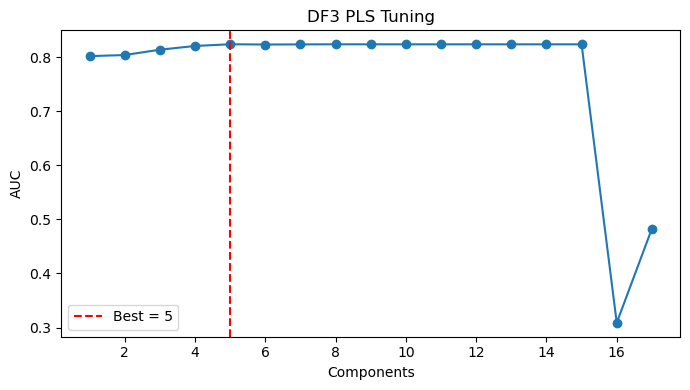


--- DF3 PLSR (5 components) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

[[972   0]
 [ 50   0]]
AUC: 0.8243


In [23]:
max_comp3 = min(20, X3_train.shape[1])
aucs3 = []
for n in range(1, max_comp3 + 1):
    pls = PLSRegression(n_components=n).fit(X3_train, y3_train)
    aucs3.append(roc_auc_score(y3_test, pls.predict(X3_test).ravel()))

best_n3 = np.argmax(aucs3) + 1
print(f'Best PLS components: {best_n3} (AUC={max(aucs3):.4f})')

plt.figure(figsize=(7, 4))
plt.plot(range(1, max_comp3+1), aucs3, marker='o')
plt.axvline(best_n3, color='red', linestyle='--', label=f'Best = {best_n3}')
plt.xlabel('Components'); plt.ylabel('AUC')
plt.title('DF3 PLS Tuning'); plt.legend(); plt.tight_layout(); plt.show()

pls3 = PLSRegression(n_components=best_n3).fit(X3_train, y3_train)
prob3_pls, auc3_pls = evaluate(pls3, X3_test, y3_test, f'DF3 PLSR ({best_n3} components)', is_pls=True)

   Model  Features/Components      AUC
Baseline                   17 0.824012
 Forward                    8 0.816461
Backward                    9 0.824712
     PCR                   11 0.818683
    PLSR                    5 0.824300


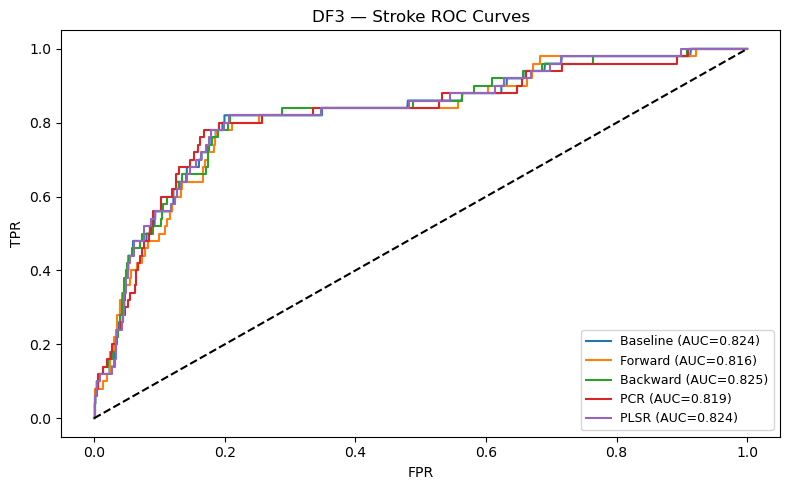

In [24]:
summary3 = pd.DataFrame({
    'Model': ['Baseline', 'Forward', 'Backward', 'PCR', 'PLSR'],
    'Features/Components': [X3_train.shape[1], len(feats_fwd3), len(feats_bwd3), n_comp3, best_n3],
    'AUC': [auc3_base, auc3_fwd, auc3_bwd, auc3_pcr, auc3_pls]
})
print(summary3.to_string(index=False))

plot_roc(y3_test, {
    'Baseline': prob3_base, 'Forward': prob3_fwd,
    'Backward': prob3_bwd, 'PCR': prob3_pcr, 'PLSR': prob3_pls
}, 'DF3 — Stroke ROC Curves')

---
## Final Summary

          DF1 Diabetes  DF2 Readmission  DF3 Stroke
Model                                              
Baseline        0.8139           0.6011      0.8240
Forward         0.8111           0.7345      0.8165
Backward        0.8122           0.8235      0.8247
PCR             0.6888           0.5337      0.8187
PLSR            0.8139           0.6900      0.8243


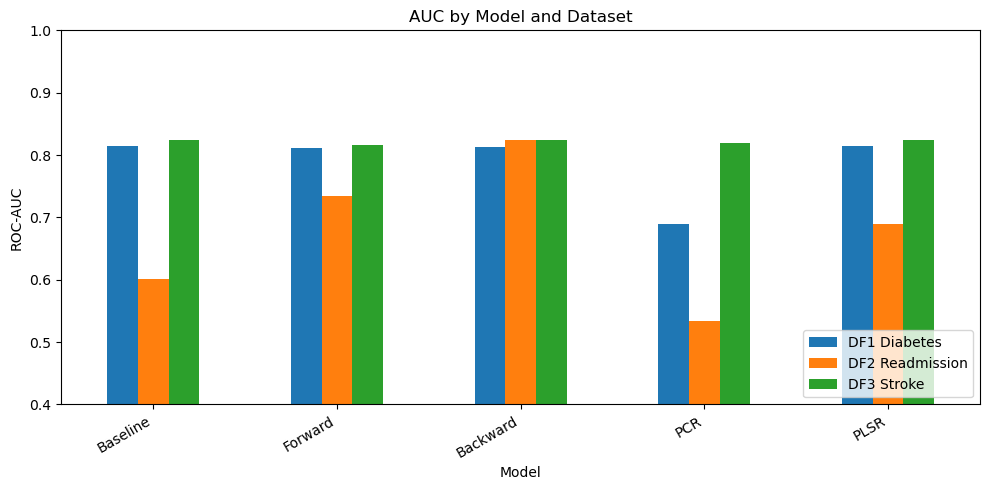

In [25]:
summary_all = pd.DataFrame({
    'Model': ['Baseline', 'Forward', 'Backward', 'PCR', 'PLSR'],
    'DF1 Diabetes':    [auc1_base, auc1_fwd, auc1_bwd, auc1_pcr, auc1_pls],
    'DF2 Readmission': [auc2_base, auc2_fwd, auc2_bwd, auc2_pcr, auc2_pls],
    'DF3 Stroke':      [auc3_base, auc3_fwd, auc3_bwd, auc3_pcr, auc3_pls],
}).set_index('Model').round(4)

print(summary_all.to_string())

summary_all.plot(kind='bar', figsize=(10, 5), ylim=(0.4, 1.0))
plt.title('AUC by Model and Dataset')
plt.ylabel('ROC-AUC'); plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()